In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/brsahan/genomic-data-for-cancer/gene_expression.csv


In [21]:
df = pd.read_csv('/kaggle/input/datasets/brsahan/genomic-data-for-cancer/gene_expression.csv')
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [22]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


,Gene One,Gene Two,Cancer Present
count,3000.000000,3000.000000,3000.000000
mean,5.600133,5.410467,0.500000
std,1.828388,1.729081,0.500083
min,1.000000,1.000000,0.000000
25%,4.300000,4.000000,0.000000
50%,5.600000,5.400000,0.500000
75%,6.900000,6.700000,1.000000
max,10.000000,10.000000,1.000000


In [23]:
df.columns = ['gene_one', 'gene_two', 'cancer']

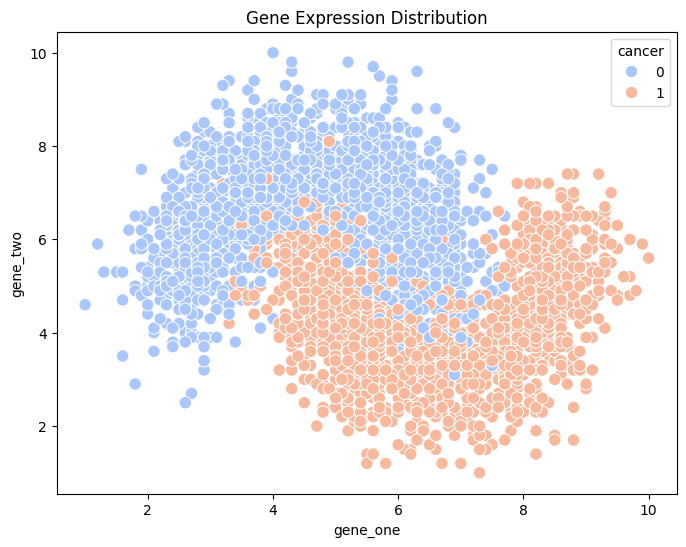

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='gene_one',
    y='gene_two',
    hue='cancer',
    palette='coolwarm',
    s=80
)

plt.title("Gene Expression Distribution")
plt.show()

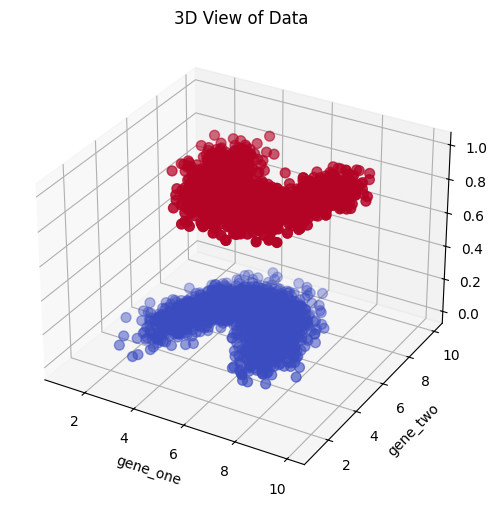

In [25]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['gene_one'],
    df['gene_two'],
    df['cancer'],
    c=df['cancer'],
    cmap='coolwarm',
    s=50
)

ax.set_xlabel('gene_one')
ax.set_ylabel('gene_two')
ax.set_zlabel('cancer')

plt.title("3D View of Data")
plt.show()

In [26]:
X = df[['gene_one','gene_two']]
y = df['cancer']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
linearmodel = SVC(kernel='linear')
linearmodel.fit(X_train,y_train)
rbfmodel = SVC(kernel='rbf')
rbfmodel.fit(X_train,y_train)

SVC()

In [30]:
print("Linear Accuracy:", accuracy_score(y_test, linearmodel.predict(X_test)))
print("RBF Accuracy:", accuracy_score(y_test, rbfmodel.predict(X_test)))

Linear Accuracy: 0.8583333333333333
RBF Accuracy: 0.9366666666666666


copied code for plot_decision_boundary in SVM


In [31]:
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(8,6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.7)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)
    ax.contour(XX, YY, Z, levels=[0], colors='black')

    plt.title(title)
    plt.xlabel("gene_one")
    plt.ylabel("gene_two")
    plt.show()

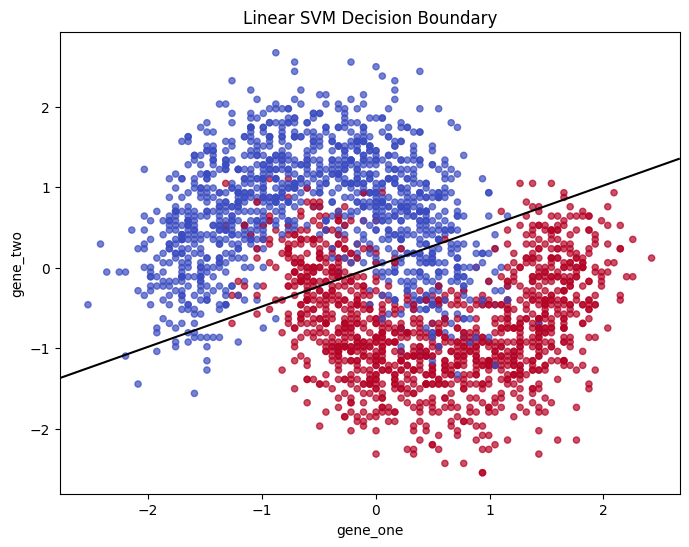

In [33]:
plot_decision_boundary(
    linearmodel,
    X_train,
    y_train,
    "Linear SVM Decision Boundary"
)

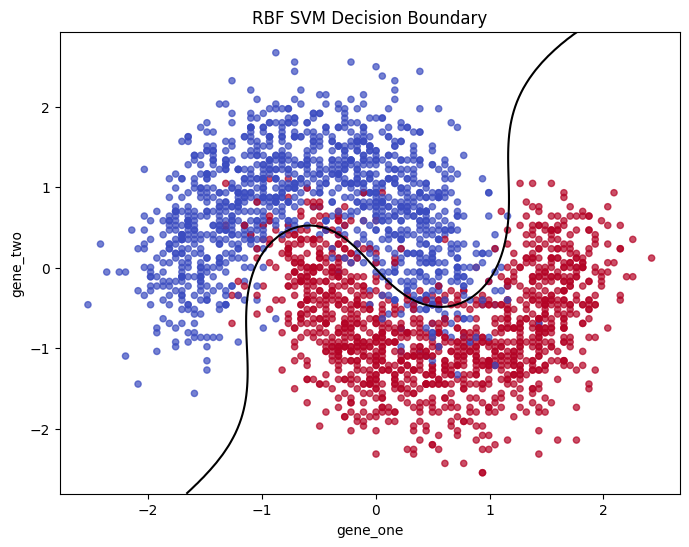

In [35]:
plot_decision_boundary(
    rbfmodel,
    X_train,
    y_train,
    "RBF SVM Decision Boundary"
)